# Nucleus 1000 ins data to keypoints

In [110]:
import numpy as np
import pandas as pd
from tools.bag_to_df import bag_topic_to_dataframe
import matplotlib.pyplot as plt 
from tools.tools import *
from dataclasses import dataclass
from scipy.spatial.transform import Rotation as R
from tools.tools import print_bag_topics
from tools.signal_properties import compare_signals


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load BAG

In [111]:
bagdir = "/root/stonefish_ros2_ws/sintef_dataset/2024-08-22_14-29-05_data.bag"
print_bag_topics(bagdir)

Topics and message types:
/bluerov2/alive                                std_msgs/msg/Float32
/bluerov2/armed                                std_msgs/msg/Float32
/bluerov2/battery                              messages/msg/BatteryStatus
/bluerov2/modes                                joystick/msg/ModeManager2
/commanded_thrust                              rospy_tutorials/msg/Floats
/controller/x                                  messages/msg/MRACOupdate
/controller/y                                  messages/msg/MRACOupdate
/controller/yaw                                messages/msg/PIDState
/controller/z                                  messages/msg/PIDState
/gui/netFollowing_manager                      messages/msg/NetFollowingManager
/guidance                                      messages/msg/GuidanceManager
/joystick                                      joystick/msg/Joystick
/joystick/dvl_reset_position                   messages/msg/BoolStamped
/joystick/init                        

# Read data

In [112]:
ins_df = bag_topic_to_dataframe(bagdir, topic="/nucleus1000dvl/ins")
# Add roll pitch yaw to ins data
quats = ins_df[["quaternion.x", "quaternion.y", "quaternion.z", "quaternion.w"]].values
eulers = R.from_quat(quats).as_euler('xyz', degrees=False)
ins_df["roll"] = eulers[:, 0]
ins_df["pitch"] = eulers[:, 1]
ins_df["yaw"] = eulers[:, 2]


dvl_position = bag_topic_to_dataframe(bagdir, topic="/sensor/dvl_position")
dvl_velocity = bag_topic_to_dataframe(bagdir, topic="/sensor/dvl_velocity")
nucleus_altitude = bag_topic_to_dataframe(bagdir, topic="/nucleus1000dvl/altimeter")
plane_position = bag_topic_to_dataframe(bagdir, topic="/navigation/plane_approximation_position")
plane_approximation = bag_topic_to_dataframe(bagdir, topic="/navigation/plane_approximation")
plane_position.info()

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')
/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 269 entries, 0 to 268
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   t                         269 non-null    float64
 1   __msgtype__               269 non-null    object 
 2   header.__msgtype__        269 non-null    object 
 3   header.frame_id           0 non-null      float64
 4   header.seq                269 non-null    int64  
 5   header.stamp.__msgtype__  269 non-null    object 
 6   header.stamp.nanosec      269 non-null    int64  
 7   header.stamp.sec          269 non-null    int64  
 8   pitch                     269 non-null    float64
 9   roll                      269 non-null    float64
 10  t_last_reset              269 non-null    float64
 11  time                      269 non-null    float64
 12  x                         269 non-null    float64
 13  y                         269 non-null    float64
 14  yaw       

# Nucleus 1000 INS

## Map To correct aixs

In [ ]:
from scipy.ndimage import gaussian_filter1d

df = ins_df.copy()

# Positions in sensor frame
x = df["positionFrame.x"].to_numpy(dtype=float)
y = df["positionFrame.y"].to_numpy(dtype=float)
z = df["positionFrame.z"].to_numpy(dtype=float)

# Orientation in sensor frame
quats = df[["quaternion.x","quaternion.y","quaternion.z","quaternion.w"]].to_numpy(dtype=float)
eul = R.from_quat(quats).as_euler('xyz', degrees=False)
roll, pitch, yaw = eul[:,0], eul[:,1], eul[:,2]

# ----- Map coords -----
x_w = y
y_w = -x
z_w = z

roll_w = pitch
pitch_w = -(roll + np.pi/2)
yaw_w = yaw

# Gaussian lowpass filter

In [ ]:
t = df["t"].to_numpy()
t0 = t[0]
t -= t0
dt = np.median(np.diff(t)) if len(t) > 1 else 0.01
fs = 1.0 / max(dt, 1e-6) # Sample frequency

def lp_gauss(signal):
    """
    Gaussian filtering with zero phase lag :)
    """
    win_sec = 1 # Window size
    FWHM = 2.355 # full width at half maximum
    sigma = (win_sec / FWHM) * fs
    return gaussian_filter1d(signal, sigma=sigma, mode='nearest')

# Smooth signals
x_s = lp_gauss(x_w)
y_s = lp_gauss(y_w)
z_s = lp_gauss(z_w)

# Unwrap vinkler for å unngå hopp ved +-pi
roll_u  = np.unwrap(roll_w)
pitch_u = np.unwrap(pitch_w)
yaw_u   = np.unwrap(yaw_w)

# filter on the complex plane for continuity
roll_s = np.angle(np.exp(1j * lp_gauss(roll_u)))
pitch_s = np.angle(np.exp(1j * lp_gauss(pitch_u)))
yaw_s = np.angle(np.exp(1j * lp_gauss(yaw_u)))

xyz_raw = np.column_stack((x_s, y_s, z_s))
rpy_raw = np.column_stack((roll_s, pitch_s, yaw_s))
time_raw = t

# Downsample

In [115]:
n = 10
xyz_downsampled  = xyz_raw[::n]
rpy_downsampled  = rpy_raw[::n]
time_downsampled = t[::n]
print(f"Num. keypoints: {len(xyz_downsampled)}")

Num. keypoints: 57


{'rmse': 0.009924195732800309, 'corr': 0.9820595343694998, 'mean_error': -0.00046797472044860286, 'kurtosis_diff': 2.0027794609030085}
{'rmse': 0.0022345113049136774, 'corr': 0.9990575074021733, 'mean_error': -0.00011788911736732422, 'kurtosis_diff': 3.286873626537826}


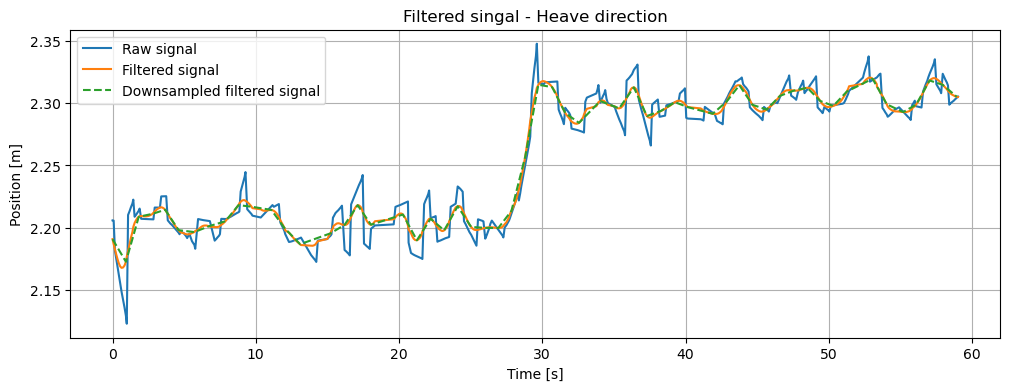

In [116]:
normalize_time(ins_df)
plt.figure(figsize=(12, 4))


plt.plot(ins_df["t"].values, ins_df["positionFrame.z"].values, label="Raw signal")
plt.plot(time_raw, z_s, label="Filtered signal")
plt.plot(time_downsampled, z_s[::n], label="Downsampled filtered signal", ls="--")


plt.title("Filtered singal - Heave direction")
plt.xlabel("Time [s]")
plt.ylabel("Position [m]")

plt.legend()
plt.grid()

comp_raw = compare_signals(ins_df["t"].values, ins_df["positionFrame.z"].values,
                       time_downsampled, z_s[::n])

comp_ds = compare_signals(time_raw, z_s,
                       time_downsampled, z_s[::n])

print(comp_raw)
print(comp_ds)

# Transform positions to match net

First, express the xyz and rpy 

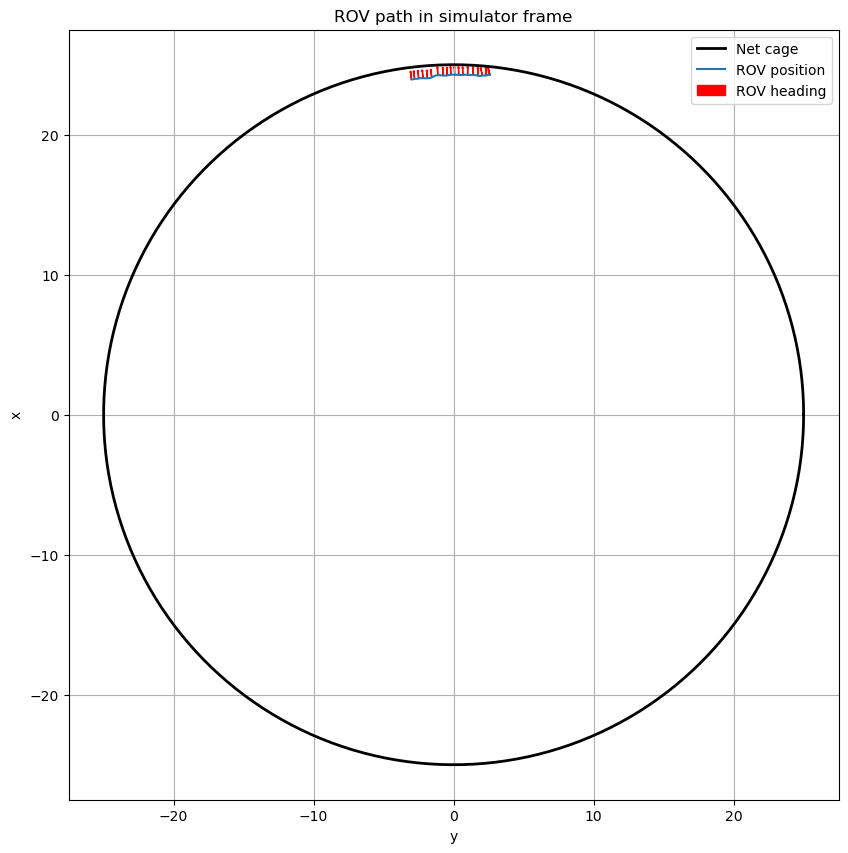

In [120]:
# transformation
cg_to_dvl = 0.153

xyz_post = np.array([23.69 - cg_to_dvl, 4.5, 0])
rpy_post = np.array([0, 0, -0.55])


xyz_transformed_ds, rpy_transformed_ds = transform_path(xyz_post, rpy_post, xyz_downsampled, rpy_downsampled)

plt.figure(figsize=(10,10))

plot_net()

plt.plot(xyz_transformed_ds[:,1], xyz_transformed_ds[:,0], label="ROV position")
plot_heading_arrows(xyz_transformed_ds, rpy_transformed_ds)


# xyz_transformed_raw, rpy_transformed_raw = transform_path(xyz_post, rpy_post, xyz_raw, rpy_raw)
# plt.plot(xyz_transformed_raw[:,1], xyz_transformed_raw[:,0], label="ROV position")
# plot_heading_arrows(xyz_transformed_raw, rpy_transformed_raw)

plt.grid()
plt.title("ROV path in simulator frame")
plt.xlabel("y")
plt.ylabel("x")

# plt.ylim(23, 26)
# plt.xlim(-4, 4)

plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

# Verify with real data

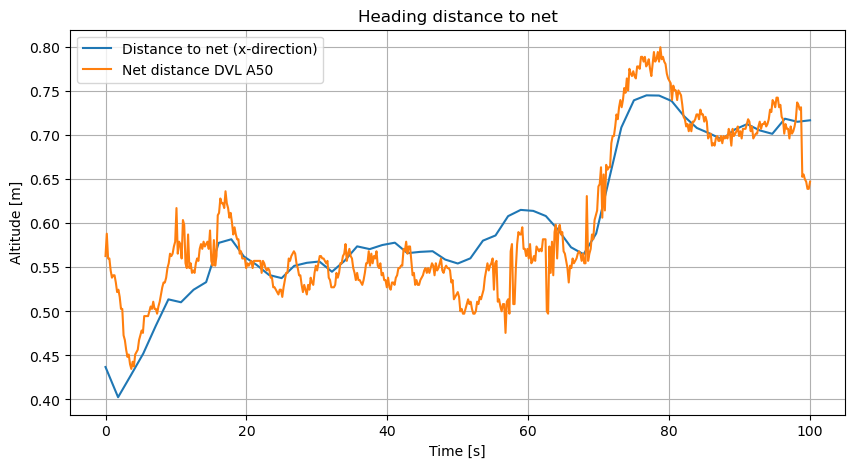

In [121]:
# Plot distance to net

def dist_to_net(y_pos):
    r = 25
    return np.sqrt(r**2 - y_pos**2)

dist = []
x_list, y_list = xyz_transformed_ds[:,0], xyz_transformed_ds[:,1]
for x, y in zip(x_list, y_list):
    
    distance = dist_to_net(y) - x - cg_to_dvl
    dist.append(distance)

dvl_altitude = dvl_velocity["altitude"].values

plt.figure(figsize=(10, 5))
plt.title("Heading distance to net")
plt.plot(np.linspace(0, 100, len(x_list)), dist, label="Distance to net (x-direction)")
plt.plot(np.linspace(0, 100, len(dvl_altitude)), dvl_altitude, label="Net distance DVL A50")
plt.xlabel("Time [s]")
plt.ylabel("Altitude [m]")
plt.grid()
plt.legend()


# To file

In [122]:
output_file = "keypoints.txt"

t = time_downsampled
x_list, y_list, z_list = xyz_transformed_ds[:,0], xyz_transformed_ds[:,1], xyz_transformed_ds[:,2]
roll_list, pitch_list, yaw_list = rpy_transformed_ds[:,0], rpy_transformed_ds[:,1], rpy_transformed_ds[:,2]

fmt = lambda v: f"{v:.4f}"
lines = []
for t, x, y, z, roll, pitch, yaw in zip(time_downsampled, x_list, y_list, z_list, roll_list, pitch_list, yaw_list):
    line = (
        f'<keypoint time="{fmt(t)}" '
        f'xyz="{fmt(x)} {fmt(y)} {fmt(z)}" '
        f'rpy="{fmt(roll)} {fmt(pitch)} {fmt(yaw)}"/>'
    )
    lines.append(line)

with open(output_file, "w") as f:
    f.write("\n".join(lines))

print(f"Wrote {len(lines)} keypoints to {output_file}")

Wrote 57 keypoints to keypoints.txt
